# CW3 Statistics for Data Science and AI - Adrielle Fuego
---
## Is the Climate Actually Changing?
---
### This report details the statistical analysis from 37 historic UK weather stations, dating back from as early as 1853 until present. The report is outlined as follows:

- Analysis on a subset of stations and the trends in rainfall **(Rainfall)**, maximum temperatures **(TMax)**, and air frost days **(Frost)** over time
- Trend in Monthly Average of Daily Maximum Temperatures **now** and in the **future**
- Changing Pattern of **Air Frost Days**
- Summary of Statistical Evidence

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stations_info = pd.read_csv('ALL-WEATHER-STATIONS.csv')

station_names = stations_info['FileName'].str.replace('data', '')

# Add ".csv" to make the true filenames
allstations = (station_names + 'data.csv').tolist()

# Make continuous time variable
def make_time(row):
    return row['Year'] + (row['Month'] - 1) / 12.0

# Load MULTIPLE station files from list
def load_multiple_stations(file_list):
    dfs = []
    
    for f in file_list:     # loop through every filename in the list
        df_station = load_station(f)
        # add the time variable
        df_station['time'] = df_station.apply(make_time, axis=1)
        
        dfs.append(df_station)
    
    # Combine all stations into one dataframe
    return pd.concat(dfs, ignore_index=True)


In [106]:
def plot_station_yearly(df, station_name):
    df_s = df[df['station'] == station_name].copy()

    # yearly averages
    yearly = (
        df_s
        .groupby('Year', as_index=False)
        .agg({
            'TMax': 'mean',
            'Rainfall': 'mean',
            
            'Frost': 'mean'
        })
    )

    yearly = yearly.set_index('Year')

    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(12, 6), sharex=True)
    
    a1.plot(yearly.index, yearly['TMax'], label='TMax')
    coef_t = np.polyfit(yearly.index, yearly["TMax"], 1)
    trend_t = np.poly1d(coef_t)
    a1.plot(yearly.index, trend_t(yearly.index), linestyle='--', color='red', label='Trend')
    a1.set_ylabel('TMax (°C)')
    a1.legend()

    a2.set_title(f"{station_name.capitalize()} : Yearly Averages")
    a2.plot(yearly.index, yearly['Rainfall'], label='Rainfall')
    coef_r = np.polyfit(yearly.index, yearly['Rainfall'], 1)
    trend_r = np.poly1d(coef_r)
    a2.plot(yearly.index, trend_r(yearly.index), linestyle='--', color='red', label='Trend')
    a2.set_ylabel('Rainfall (mm)')
    a2.legend()

    a3.plot(yearly.index, yearly["Frost"], label='Frost')
    coef_f = np.polyfit(yearly.index, yearly['Frost'], 1)
    trend_f = np.poly1d(coef_f)
    a3.plot(yearly.index, trend_f(yearly.index), linestyle='--', color='red', label='Trend')
    a3.set_ylabel('Frost (days)')
    a3.set_xlabel('Year')
    a3.legend()

    plt.tight_layout()
    plt.show()

### Climate Trends Over Time

In this section, I explore the trends in climate through the variables: **TMax (max temperature), Rainfall, and Air Frost Days** across stations **Cardiff, Leuchars, and Eastbourne**. I have chosen these 3 stations as they are geographically diverse and respresent different kinds of climates in the UK and will point towards a nationwide trend rather than any local phenomena that may impact the trends over time. **Note:** that these graphs depict the yearly averages of each variable, as a time series featuring every observation would be noisy and impact visual clarity due to each observation representing a different month. Aggregating the variables by mean per year makes these graphs readable while still maintaining the overall trend in data.

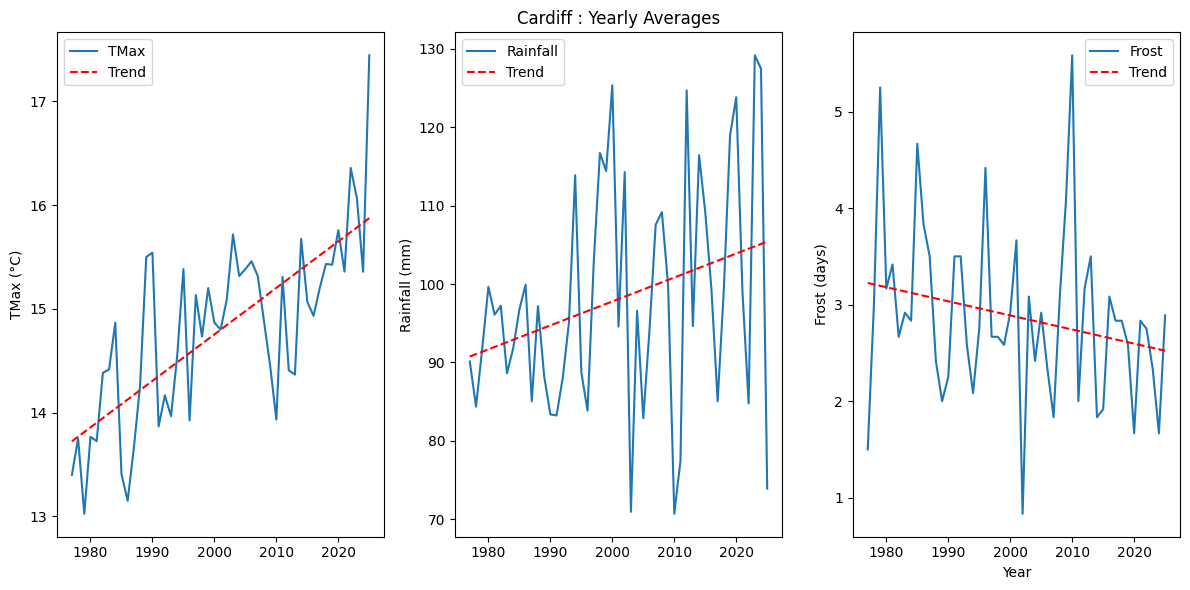

In [110]:
df_allstations = load_multiple_stations(allstations)
df_allstations
plot_station_yearly(df_allstations, 'cardiff')


#### Cardiff Climate Trends 1980 - Present
- The yearly averages for Cardiff show clear qualitative signs of climate change.
- Max temperature (TMax) displays a consistent upward trend, with later years noticeably warmer than earlier decades
- Rainfall is highly variable, but the trend line indicates a slight increase over time.
- In contrast, air frost days show a declining pattern, suggesting milder winters.

Overall, Cardiff shows the typical pattern expected under a warming and changing climate: higher temperatures, slightly wetter conditions, and fewer frosts.


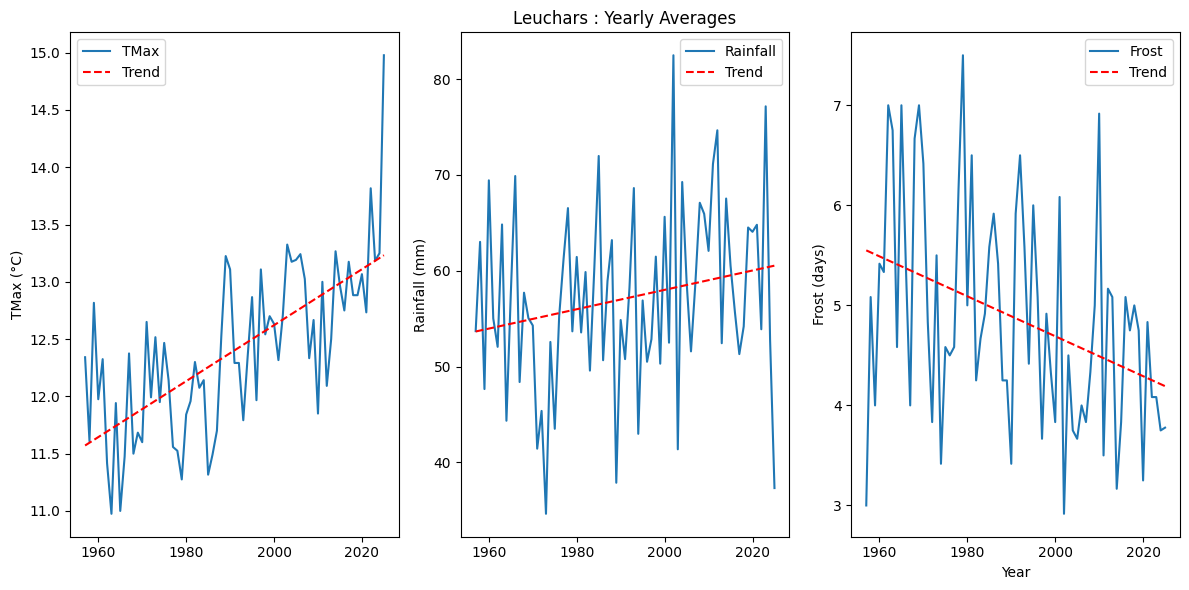

In [111]:
plot_station_yearly(df_allstations, 'leuchars')


#### Leuchars Climate Trends 1960 - Present

- Leuchars shows similar long-term patterns to Cardiff.
- Max temperature (TMax) increases steadily over time, indicating a gradual warming trend in this northern region.
- Rainfall is highly variable but shows a slight upward trend, suggesting conditions may be becoming wetter over time and more unpredictable 
- Frost days show a clear decline, consistent with milder winters and fewer prolonged cold periods.

Overall, Leuchars provides further qualitative evidence of warming temperatures, slightly higher and more erratic rainfall suggesting weather cycle changes, and fewer cold extremes. 

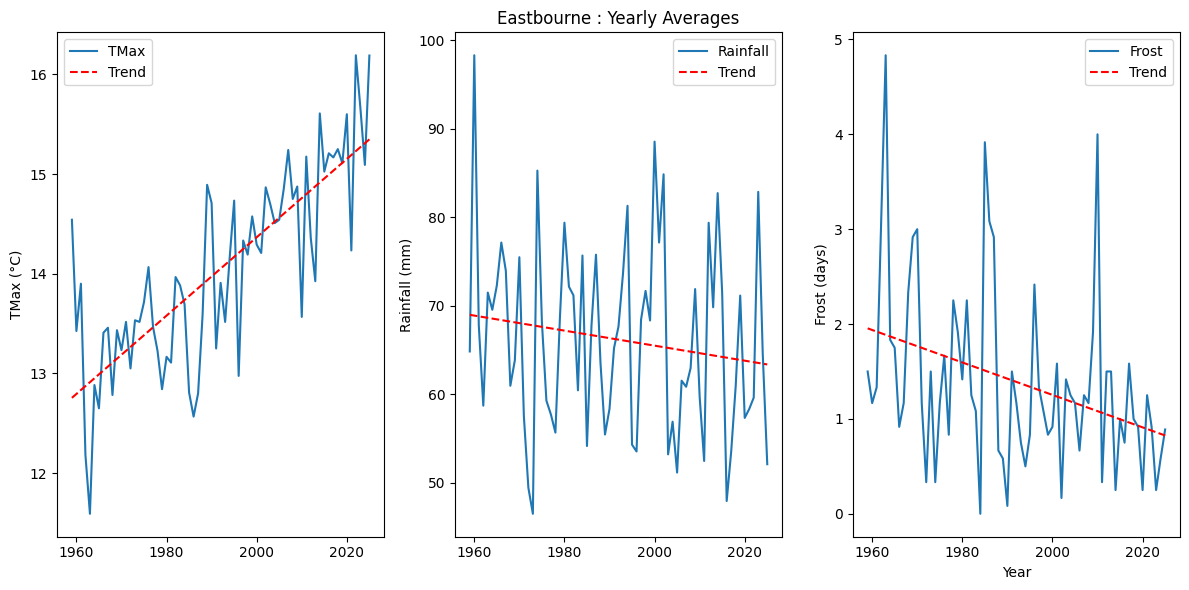

In [112]:
plot_station_yearly(df_allstations, 'eastbourne')


#### Eastbourne CLimate Trends 1960 - Present

- Eastbourne shows similar trends in max temperature and air frost days as Cardiff and Leuchars
- Eastbourne shows a strong upward trend in max temperature, indicating clear warming over time in this south-east coastal region.
- Rainfall fluctuates heavily from year to year, but the trend line suggests a slight decrease, unlike the increases seen at the other stations.
- Frost days also show a steady decline, pointing to progressively milder winters.

Overall, Eastbourne’s data gives more evidence of climate change with its warmer temperatures, similar erratic rainfall, and a clear decline in frost.

### Summary

Although Leuchars (Scotland), Cardiff (Wales), and Eastbourne (South-East England) represent very different parts of the UK, all three stations show remarkably similar long-term patterns. These trends appearing consistently across distant and contrasting regions makes the changes unlikely to be random local fluctuations. Instead, they provide clear evidence of a widespread, country-wide shift in climate, consistent with the broader effects of climate change.

### Trend in Monthly Average of Daily Maximum Temperatures Now and in the Future

#### Understanding the Temperature Pattern at Armagh
To examine how well regression model fits the data, I first used the station Armagh as an example. I fitted a model to Armagh’s monthly maximum temperatures that captures both the yearly seasonal cycle and any long-term change. The key results are:

- Baseline: 12.5°C

- Seasonal variation: strong (sin and cos terms)
 
- Warming rate: 0.00050°C per month ≈ 0.06°C per decade

- Fit quality: $R^2$= 0.91


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.utils import resample

def add_time(df_allstations):
  
    df = df_allstations.dropna(subset=["TMax"]).copy()
    df = df.sort_values(["Year", "Month"]).reset_index(drop=True)
    
    # time index relative to first row of THIS station
    df["t"] = (df["Year"] - df["Year"].iloc[0]) * 12 + (df["Month"] - df["Month"].iloc[0])
    df["time"] = df["Year"] + (df["Month"] - 1) / 12.0

    omega = 2 * np.pi / 12
    df["sin_term"] = np.sin(omega * df["t"])
    df["cos_term"] = np.cos(omega * df["t"])
    
    return df

df_armagh = df_allstations[df_allstations["station"] == 'armagh'].copy()
df_armagh = add_time(df_armagh)

def fit_tmax_regression(df):

    y = df['TMax'].values
    X = np.column_stack((df['t'].values, df["sin_term"].values, df["cos_term"].values))
    
    reg = LinearRegression().fit(X, y)
    y_hat = reg.predict(X)
    resid = y - y_hat
    
    return reg, X, y, y_hat, resid

# fit regression: TMax ~ t + sin_term + cos_term
reg_armagh, X_armagh, y_armagh, yhat_armagh, resid_armagh = fit_tmax_regression(df_armagh)

print(f"Regression results for {'Armagh'}:")
print(f"Intercept      : {reg_armagh.intercept_:.4f}")
print(f"beta_t (trend) : {reg_armagh.coef_[0]:.6f}  (per month)")
print(f"beta_sin       : {reg_armagh.coef_[1]:.4f}")
print(f"beta_cos       : {reg_armagh.coef_[2]:.4f}")
print(f"R^2            : {reg_armagh.score(X_armagh, y_armagh):.3f}")


Regression results for Armagh:
Intercept      : 12.5042
beta_t (trend) : 0.000500  (per month)
beta_sin       : 6.2284
beta_cos       : -0.3038
R^2            : 0.910


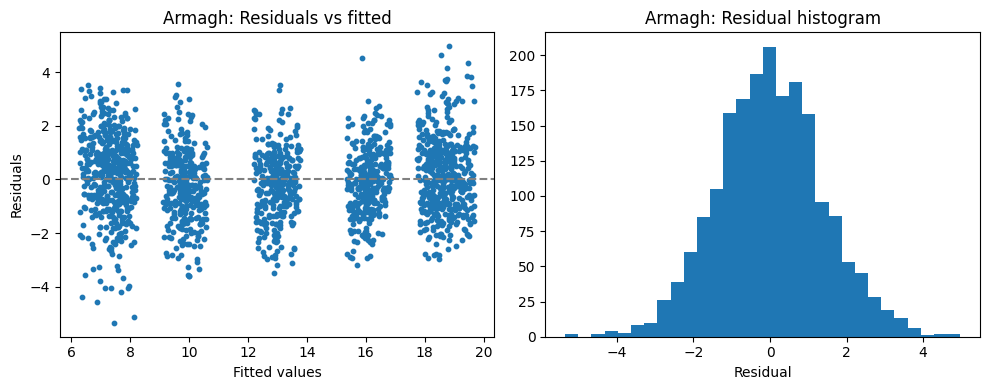

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Residuals vs fitted
plt.subplot(1,2,1)
plt.scatter(yhat_armagh, resid_armagh, s=10)
plt.axhline(0, linestyle="--", color="grey")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title(f"{'Armagh'}: Residuals vs fitted")

# Histogram of residuals
plt.subplot(1,2,2)
plt.hist(resid_armagh, bins=30)
plt.xlabel("Residual")
plt.title(f"{'Armagh'}: Residual histogram")

plt.tight_layout()
plt.show()


### Why examine the residuals?

Residuals show what the model fails to capture.
These plots show:

- The residuals vs fitted plot shows no structure, meaning the linear trend + seasonal cycle is appropriate.
- The residual histogram is roughly symmetric, supporting the assumption that remaining variation is random noise rather than systematic error.
- This gives confidence that the model is capturing the key temperature patterns without obvious bias.

#### Why this regression matters for later results

Later on, the bootstrap confidence intervals, the prediction intervals, and the all-station comparison rely on this regression being reasonable, so it is importatnt to ensure that the model performs well.

If the residuals looked structured or non-random, the bootstrap would not produce reliable uncertainty estimates.
Since the model fits well, the bootstrap-based trend estimates and predictions for future temperatures are built on a sound statistical foundation.

In [115]:

np.random.seed(7024)  # for reproducibility

def bootstrapC(data, cols, repeats, func):
    result = pd.DataFrame(data=dict([(c, np.empty(repeats)) for c in cols]))
    
    for i in range(repeats):
        result.iloc[i] = func(resample(data))  # default: resample same size, with replacement
    return result



In [116]:
def bootstrap_trend_CI(df, repeats=2000, alpha=0.05):
    
    reg, X, y, y_hat, resid = fit_tmax_regression(df)
    
    # Put residuals in a 1-column DataFrame so bootstrapC can resample them
    resid_df = pd.DataFrame({'resid': resid})
    
    # Inner function: called on each bootstrap resampled residual dataframe
    def do_regression_on_bootstrap_residuals(resid_sample_df):
        # residual* values
        resid_star = resid_sample_df['resid'].values
        
        # y* = y_hat + residual*
        y_star = y_hat + resid_star
        
        # Fit regression on same X, new y*
        reg_star = LinearRegression().fit(X, y_star)
        y_hat_star = reg_star.predict(X)
        
        # Extract coefficients in order: [Intercept, beta_t, beta_sin, beta_cos]
        intercept_star = reg_star.intercept_
        beta_t_star, beta_sin_star, beta_cos_star = reg_star.coef_
        R2_star = reg_star.score(X, y_star)
        
        return [intercept_star, beta_t_star, beta_sin_star, beta_cos_star, R2_star]
    
    cols = ['Intercept', 'beta_t', 'beta_sin', 'beta_cos', 'R2']
    
    bstrap = bootstrapC(resid_df, cols, repeats, do_regression_on_bootstrap_residuals)
    
    # Point estimate from original fit
    beta_t_hat = reg.coef_[0]
    
    # Percentile CI for β1 (trend)
    lower = bstrap['beta_t'].quantile(alpha / 2)
    upper = bstrap['beta_t'].quantile(1 - alpha / 2)
    
    return beta_t_hat, lower, upper, bstrap


Trend estimate beta_t (per month) : 0.000500
Bootstrap 95% CI (per month)      : [0.000385, 0.000610]
Trend per decade (x120)           : 0.060 °C/decade
95% CI per decade                 : [0.046, 0.073]


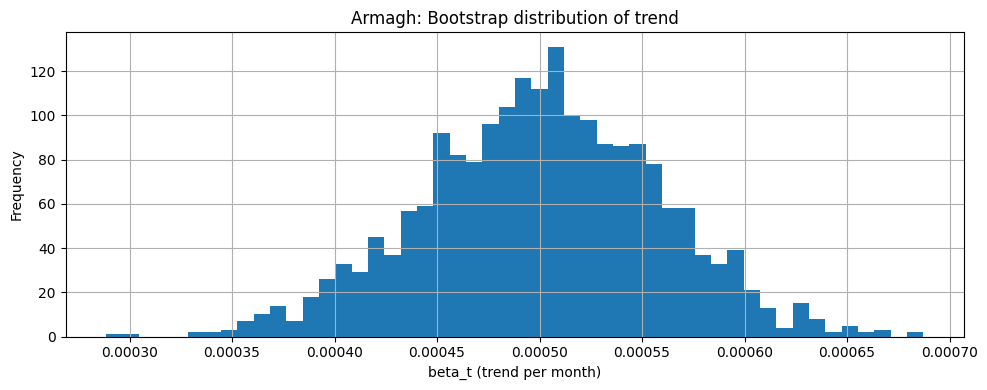

In [117]:

beta_t_hat_armagh, ci_low_armagh, ci_high_armagh, bstrap_armagh = bootstrap_trend_CI(
    df_armagh,
    repeats=2000,
    alpha=0.05
)

print(f"Trend estimate beta_t (per month) : {beta_t_hat_armagh:.6f}")
print(f"Bootstrap 95% CI (per month)      : [{ci_low_armagh:.6f}, {ci_high_armagh:.6f}]")

print(f"Trend per decade (x120)           : {beta_t_hat_armagh*120:.3f} °C/decade")
print(f"95% CI per decade                 : [{ci_low_armagh*120:.3f}, {ci_high_armagh*120:.3f}]")

plt.figure(figsize=(10,4))
bstrap_armagh["beta_t"].hist(bins=50)
plt.xlabel("beta_t (trend per month)")
plt.ylabel("Frequency")
plt.title(f"{'Armagh'}: Bootstrap distribution of trend")
plt.tight_layout()
plt.show()



### Bootstrap Confidence Interval for the Warming Trend (Armagh)

To understand how much the warming rate at Armagh might vary due to natural fluctuations in the data, I used a residual bootstrap. This repeatedly simulates alternative histories of temperature by resampling the model’s residuals and refitting the trend each time.

Bootstrap results:

- Trend estimate: **0.000500 per month**
- 95% bootstrap CI: **[0.000392, 0.000607] per month**

**Note:**
As monthly changes are extremely small, it is more meaningful to express the trend per decade, which is easier to interpret in a climate context. Since 1 decade is 120 months, the trend becomes:

- Trend estimate: **0.06°C per decade**
- 95% CI: **[0.047°C, 0.073°C] per decade**

Interpretation:

The entire confidence interval is above zero, which means the analysis consistently indicates long-term warming at Armagh even after accounting for uncertainty. The histogram of the bootstrap estimates is roughly symmetric and centred near the original trend estimate, suggesting that the model is **stable** , the trend estimate is **not sensitive** to random fluctuations in the data, and the bootstrap interval provides a **reliable measure** of uncertainty.

This single-station example illustrates the approach used later when applying the bootstrap to all 37 UK stations.

In [118]:
stations = df_allstations['station'].unique()
trend_results = []

for st in stations:
    df_st = df_allstations[df_allstations['station'] == st]
    df_st_prepped = add_time(df_st)
    
    # skip if too little data
    if len(df_st_prepped) < 10:
        continue
    
    beta_t_hat, ci_low, ci_high, bstrap = bootstrap_trend_CI(df_st_prepped, repeats=2000)
    
    trend_results.append({
        'station': st,
        'beta_t': beta_t_hat,
        'CI_low': ci_low,
        'CI_high': ci_high,
        'trend_per_decade': beta_t_hat * 120,
        'CI_low_decade': ci_low * 120,
        'CI_high_decade': ci_high * 120
    })

trend_df = pd.DataFrame(trend_results)
trend_df


,station,beta_t,CI_low,CI_high,trend_per_decade,CI_low_decade,CI_high_decade
0,aberporth,0.001004,0.000735,0.001277,0.120427,0.088165,0.153205
1,armagh,0.000500,0.000385,0.000606,0.060011,0.046218,0.072760
2,ballypatrick,0.001983,0.001616,0.002359,0.237922,0.193905,0.283086
3,bradford,0.001249,0.001052,0.001458,0.149825,0.126272,0.174974
4,braemar,0.001936,0.001458,0.002410,0.232347,0.174980,0.289172
5,camborne,0.002533,0.001956,0.003140,0.303989,0.234728,0.376770
6,cambridge,0.002864,0.002358,0.003400,0.343667,0.282923,0.408007
7,cardiff,0.003386,0.002703,0.004076,0.406355,0.324412,0.489118
8,chivenor,0.001583,0.001148,0.002009,0.189934,0.137752,0.241049
9,cwmystwyth,0.001923,0.001270,0.002589,0.230781,0.152390,0.310715


### Confidence Intervals for the Rate of Temperature Change Across all 37 Stations

I used the residual bootstrap to quantify uncertainty in the warming trend at each of the 37 stations. For each station, I refitted the model thousands of times to simulated data created by resampling the residuals, and used the resulting distribution of trend estimates to form a 95% confidence interval. Most stations show a clearly positive interval, indicating consistent evidence of long-term warming across the UK.


In [119]:
stations_info["station"] = (
    stations_info["FileName"]
    .str.replace("data", "", regex=False)  
    .str.strip()
    .str.lower()
)

stations_info = stations_info.rename(columns={"Longnitude": "Longitude"})
trend_df["station"] = trend_df["station"].astype(str).str.strip().str.lower()

trend_df = trend_df.merge(
    stations_info[["station", "Longitude", "Latitude"]],
    on="station",
    how="left"
)


In [120]:

def assign_region(lat, lon):
    # Scotland (lat >= 55.5)
    if lat >= 55.5:
        return "Scotla\nd"
    
    # Northern Ireland (approx bounding box)
    if 54.0 <= lat <= 55.5 and lon <= -5.0:
        return "Northern Ireland"
    
    # Wales
    if 51.3 <= lat <= 53.5 and lon <= -3.5:
        return "Wales"
    
    # North England
    if 53.5 <= lat < 55.5:
        return "North England"
    
    # Midlands
    if 52.5 <= lat < 53.5:
        return "Midlands"
    
    # South West England
    if lat < 52.5 and lon <= -3.0:
        return "South West England"
    
    # South East England 
    return "South East England"
    
trend_df["Region"] = trend_df.apply(
    lambda row: assign_region(row["Latitude"], row["Longitude"]),
    axis=1
)
region_summary = (
    trend_df
    .groupby('Region')['trend_per_decade']     
    .agg(['mean', 'min', 'max', 'count'])       
    .sort_values('mean')                        
)

region_summary

,mean,min,max,count
Region,,,,
Northern Ireland,0.148967,0.060011,0.237922,2
Wales,0.158504,0.120427,0.230781,3
Scotla\nd,0.158913,0.066996,0.309616,9
Midlands,0.221955,0.115166,0.329497,5
North England,0.224937,0.104532,0.502179,5
South East England,0.231227,0.063214,0.383213,10
South West England,0.300093,0.189934,0.406355,3


### Confidence Intervals for the Rate of Temperature Change Across all 37 Stations

To make these results easier to interpret, I **grouped the stations by region**. Individual stations can be influenced by very local conditions, so grouping them helps reveal broader geographic patterns that are less visible when looking at stations one by one. Regions tend to share similar climate influences, so averaging within them provides a clearer picture of how warming varies across the country.

When viewed by region, a clear pattern emerges. **Northern Ireland, Wales and Scotland** show the **smallest average warming** (around 0.15-0.16°C per decade), while the **Midlands, North England and South East England** show **stronger warming** (around 0.22-0.23°C per decade). **South West England** shows the **largest mean warming**, around 0.30°C per decade. Overall, the results suggest a broad North–South gradient, with southern regions warming faster than northern and western parts of the UK.

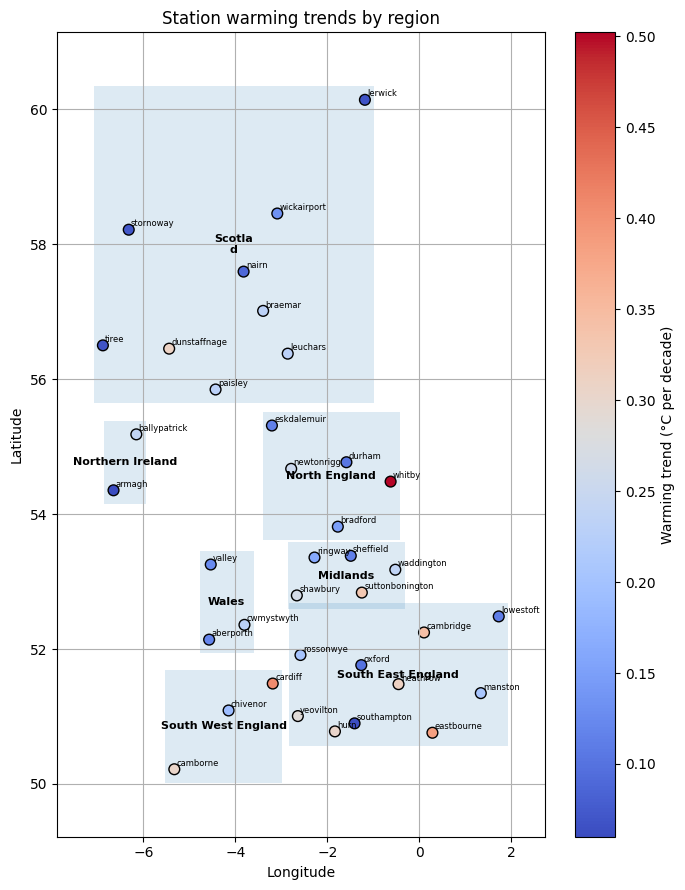

In [121]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# bounds per region
region_bounds = (
    trend_df
    .groupby("Region")
    .agg(
        lon_min=("Longitude", "min"),
        lon_max=("Longitude", "max"),
        lat_min=("Latitude", "min"),
        lat_max=("Latitude", "max"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 9))

# rect for each region
for i, row in region_bounds.iterrows():
    pad_lon = 0.2
    pad_lat = 0.2

    x0 = row["lon_min"] - pad_lon
    y0 = row["lat_min"] - pad_lat
    width = (row["lon_max"] - row["lon_min"]) + 2 * pad_lon
    height = (row["lat_max"] - row["lat_min"]) + 2 * pad_lat

    rect = patches.Rectangle(
        (x0, y0),
        width,
        height,
        alpha=0.15,         
        edgecolor="none"
    )
    ax.add_patch(rect)

    # Region label in the middle of the box
    ax.text(
        x0 + width / 2,
        y0 + height / 2,
        row["Region"],
        ha="center",
        va="center",
        fontsize=8,
        weight="bold"
    )


sc = ax.scatter(
    trend_df["Longitude"],
    trend_df["Latitude"],
    c=trend_df["trend_per_decade"],
    cmap="coolwarm",
    s=60,
    edgecolor="black"
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Warming trend (°C per decade)")

for _, row in trend_df.iterrows():
    ax.text(
        row["Longitude"] + 0.05,
        row["Latitude"] + 0.05,
        row["station"],
        fontsize=6
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Station warming trends by region")

ax.set_xlim(trend_df["Longitude"].min() - 1, trend_df["Longitude"].max() + 1)
ax.set_ylim(trend_df["Latitude"].min() - 1, trend_df["Latitude"].max() + 1)

ax.grid(True)
plt.tight_layout()
plt.show()



### Visualising Spatial Patterns in Warming Trends Across all Stations

To complement the numerical comparison of confidence intervals, I plotted each station on a map using its **latitude and longitude** and coloured it by its **estimated warming trend**. Grouping stations by region and shading the regional areas helps reveal spatial structure that is harder to detect from tables alone.

The heatmap above shows how the warming trends vary across the UK when plotted at each station’s geographic location. Grouping stations into their broader regions makes the spatial pattern easier to see: most of the strongest warming appears across southern England, particularly in the South West and South East, while stations in Scotland, Wales and Northern Ireland generally show smaller trends. The gradual shift from lower trends in the North and West to higher trends in the south and east highlights a clear geographic gradient in the rate of temperature change.


In [122]:
def bootstrap_prediction_interval(df, target_year=2075, target_month=8, repeats=2000, alpha=0.05):
    
    reg, X, y, y_hat, resid = fit_tmax_regression(df)
    
    t_target = (target_year - df['Year'].iloc[0]) * 12 + (target_month - df['Month'].iloc[0])
    omega = 2 * np.pi / 12
    sin_target = np.sin(omega * t_target)
    cos_target = np.cos(omega * t_target)
    
    x_new = np.array([[t_target, sin_target, cos_target]])
    
    resid_df = pd.DataFrame({'resid': resid})
    
    def do_prediction_for_bootstrap(resid_sample_df):
        # residual* (for fitting y*)
        resid_star = resid_sample_df['resid'].values
        
        # Create y* for this bootstrap sample
        y_star = y_hat + resid_star
        
        # Refit regression on y*
        reg_star = LinearRegression().fit(X, y_star)
        
        # Predicted mean at x_new under this bootstrap model
        y_mean_star = reg_star.predict(x_new)[0]
        
        # Extra residual draw to represent future random variation
        eps_new = np.random.choice(resid)
        
        # Full prediction for future observation
        y_pred_star = y_mean_star + eps_new
        
        return [y_pred_star]
    
    cols = ['y_pred']
    bstrap_pred = bootstrapC(resid_df, cols, repeats, do_prediction_for_bootstrap)
    
    # Prediction interval from percentiles
    lower = bstrap_pred['y_pred'].quantile(alpha / 2)
    upper = bstrap_pred['y_pred'].quantile(1 - alpha / 2)
    
    # Point prediction from original regression
    point_pred = reg.predict(x_new)[0]
    
    return point_pred, lower, upper, bstrap_pred


In [123]:
df_cambridge = df_allstations[df_allstations["station"] == 'cambridge'].copy()
df_cambridge = add_time(df_cambridge)

In [ ]:

armagh_mean = df_armagh[df_armagh["Month"] == 8]["TMax"].mean()
cam_mean = df_cambridge[df_cambridge["Month"] == 8]["TMax"].mean()
pred_armagh, low_armagh, high_armagh, _ = bootstrap_prediction_interval(df_armagh)
pred_cam, low_cam, high_cam, _ = bootstrap_prediction_interval(df_cambridge)

stations = ["Armagh", "Cambridge"]
historic_means = [armagh_mean, cam_mean]
predicted_means = [pred_armagh, pred_cam]

x = np.arange(len(stations))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, historic_means, width, label="Historic August Mean", color="skyblue")
plt.bar(x + width/2, predicted_means, width, label="Predicted August 2075", color="salmon")

plt.xticks(x, stations)
plt.ylabel("TMax (°C)")
plt.title("Historic vs Predicted August Temperatures (Mean Only)")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


### Predictive Interval for August 2075 (Armagh and Cambridge)

To explore how August temperatures might change in the future, I repeatedly resampled the model’s residuals, refits the regression, that **reflects natural year-to-year variability**. The spread of these simulated predictions shows the likely range of temperatures in 2075.

I used **Armagh and Cambridge** as examples because they represent two very **different UK climates**: Armagh is cooler and more westerly, while Cambridge is in the warm, fast-warming South East. Comparing these two stations highlights how future conditions may differ across the country. For interpretation, I compared the 2075 predictions to each station’s historic August mean. The mean summarises typical August conditions and is directly comparable to the regression model’s predicted average. Unlike using historic extremes (min/max), the mean provides a stable, representative baseline for judging future change.

This plot compares each station’s historic mean August temperature with its **predicted mean** for August 2075. I use the mean as it **represents typical summer conditions** and aligns with the regression model’s prediction of the expected average temperature. For Armagh, the predicted 2075 value is very **close** to the historic mean, reflecting the relatively weak warming trend in this cooler northern station. In contrast, Cambridge shows a **clear increase** relative to its historic mean, consistent with its stronger long-term warming trend.

### Section Summary

Overall, the analysis shows clear evidence of long-term warming across the UK. The regression model provided a good fit for all stations, and the bootstrap confidence intervals confirmed that the warming trend is positive almost everywhere, with the strongest increases in southern and eastern regions. Predictive intervals for August 2075 suggest that some stations, such as Cambridge, are likely to experience noticeably warmer typical summer conditions, while others with weaker trends, like Armagh, may see only modest changes relative to their historical averages. Taken together, these results illustrate both the consistency of UK-wide warming and the substantial geographic variation in its magnitude.

In [96]:
import pandas as pd
import numpy as np
from scipy import stats

def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

def assign_decade(year):
    decade_start = (year // 10) * 10
    return f"{decade_start}s"

def make_frost_table(station_df, season="Winter"):
    df = station_df.dropna(subset=["Frost", "Year", "Month"]).copy()


    df["Season"] = df["Month"].apply(assign_season)
    df["Decade"] = df["Year"].apply(assign_decade)

    df_season = df[df["Season"] == season]

    if df_season.empty:
        return None  # no data for that season

    # Total frost days per decade
    frost = df_season.groupby("Decade")["Frost"].sum()

    # Number of months per decade in that season
    n_months = df_season.groupby("Decade")["Month"].count()

    # Approximate possible days = months * 30.44
    possible_days = n_months * 30.44

    df_table = pd.DataFrame({
        "Frost": frost,
        "NoFrost": possible_days - frost
    })

    return df_table



In [97]:
def chi_square_frost(station_df, station_name = 'Unknown', season="Winter"):
   
    df = make_frost_table(station_df, season=season)

    if df is None:
        return None

    df = df[df.sum(axis=1) > 0]

    if df.shape[0] <= 1:
        return None

    if (df.sum(axis=0) == 0).any():
        return None

    test_stat, p_value, dof, expected = stats.chi2_contingency(df, correction=False)

    return test_stat, p_value, dof, df, expected


### Changing Pattern of Air Frost Days: Chi-Squared Tests

To explore whether frost frequencies have changed over time, I began with examining a single station in detail before expanding to all 37 stations. Using Armagh as an example, I illustrate how the chi-squared test is applied and how deviations from expected frost counts reveal changes across decades.

#### Example Station Analysis: Armagh (Winter Season)

To illustrate how the chi-squared test results can be interpreted, I present below the “observed minus expected” values for Armagh in winter. Positive values indicate that the decade had more frost days than would be expected if frost occurrence were independent of time; negative values indicate fewer frost days than expected.

The chi-squared test for Armagh in winter gave:

**χ²(16) = 170.17**

**||p-value = 7.78 × 10⁻²⁸**

This extremely small p-value provides strong evidence that winter frost days **have not remained constant** across decades, meaning frost frequency depends on time.

In [99]:
chi_square_frost(df_armagh, station_name="Armagh", season="Winter")
test_stat, pval, dof, obs, expected = chi_square_frost(
    df_allstations[df_allstations.station == "armagh"],
    season="Winter"
)

print("Chi-squared test statistic:", test_stat)
print("Degrees of freedom:", dof)
print("p-value:", pval)


Chi-squared test statistic: 170.17194933069956
Degrees of freedom: 16
p-value: 7.780472866982086e-28


In [100]:
obs_minus_exp = obs - expected
obs_minus_exp_rounded = obs_minus_exp.round(1)
obs_minus_exp_rounded


,Frost,NoFrost
Decade,,
1860s,-34.2,34.2
1870s,35.2,-35.2
1880s,0.2,-0.2
1890s,16.2,-16.2
1900s,-25.8,25.8
1910s,-18.8,18.8
1920s,-82.8,82.8
1930s,-13.8,13.8
1940s,-22.8,22.8


### Observed – Expected Frost Counts (Armagh, Winter)

#### What the Observed - Expected Table Shows

The table displays, for each decade, the difference between the observed number of winter frost days, and the expected number assuming frost occurrence is independent of decade. A chi-squared test compares these observed and expected counts.

A positive value in the Frost column means the decade had more frost days than expected. A negative value means the decade had fewer frost days than expected.
The NoFrost column shows the opposite deviation.

Large deviations in either direction indicate decades that differ strongly from what would be expected if frost patterns had remained stable over time.

This table helps visualise where the chi-squared test finds departures from independence and highlights which decades contribute most to the test statistic.

#### Interpretation

The pattern shows that early decades (e.g., 1870s, 1890s) had more frost days than expected. Some mid-20th-century decades (e.g., 1950s, 1960s, 1980s) show large positive deviations, indicating exceptionally frosty winters. More recent decades (1990s–2010s) show negative deviations, meaning fewer frost days than expected.

This pattern is consistent with a long-term decline in winter frost frequency at Armagh.

#### Summary

Overall, the chi-squared test and deviation table provide clear evidence that winter frost days at Armagh have changed over time, with a noticeable shift towards fewer frosty days in recent decades. The Armagh example shows how changes in frost frequency appear at an individual station. To understand how widespread these changes are, I now apply the same chi-squared analysis to all 37 stations and summarise the results to highlight seasonal differences and variation across the UK network.


In [103]:
seasons = ["Winter", "Spring", "Summer", "Autumn"]

results_37 = []

for station_name, station_df in df_allstations.groupby("station"):
    for season in seasons:
        res = chi_square_frost(station_df, season=season)

        if res is not None:
            test_stat, pval, dof, df_table, expected = res

            results_37.append({
                "station": station_name,
                "Season": season,
                "test_stat": float(test_stat),
                "p_value": float(pval),
                "dof": int(dof)
            })

results_37_df = pd.DataFrame(results_37)

alpha = 0.05
results_37_df["significant"] = results_37_df["p_value"] < alpha

results_37_df


,station,Season,test_stat,p_value,dof,significant
0,aberporth,Winter,124.436796,9.112350e-24,7,True
1,aberporth,Spring,36.738147,5.257870e-06,7,True
2,aberporth,Autumn,11.439464,1.205654e-01,7,False
3,armagh,Winter,170.171949,7.780473e-28,16,True
4,armagh,Spring,86.727353,9.980397e-12,16,True
...,...,...,...,...,...,...
120,wickairport,Summer,4.713828,8.585072e-01,9,False
121,wickairport,Autumn,44.351348,1.215834e-06,9,True
122,yeovilton,Winter,29.803547,4.283681e-05,6,True
123,yeovilton,Spring,18.001025,6.229633e-03,6,True


### Chi-squared results for all stations

The table above summarises the chi-squared tests for every station and season, showing the test statistic, degrees of freedom and p-value, with a flag indicating whether the result is significant at the 5% level. This provides the full set of numerical results required for all 37 stations. 

For interpretability, I do not discuss each row individually; instead, I use these values to construct seasonal summaries and graphics (e.g. the counts of significant stations by season and the winter strength-of-evidence plot), which make the overall patterns much easier to see and are shown below.


In [49]:
alpha = 0.05 

results_37_df["significant"] = results_37_df["p_value"] < alpha

season_summary = (
    results_37_df
    .groupby("Season")["significant"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "n_significant", "count": "n_tests"})
)

season_summary["prop_significant"] = season_summary["n_significant"] / season_summary["n_tests"]

season_summary

,n_significant,n_tests,prop_significant
Season,,,
Autumn,33,37,0.891892
Spring,32,37,0.864865
Summer,2,14,0.142857
Winter,36,37,0.972973


#### Interpretation of Seasonal Significance Rates

Most stations show significant changes in winter, autumn, and spring frost frequencies, with winter highest at 97%. Summer shows little evidence of change, which is expected given how rare summer frost is. Overall, this indicates that frost patterns have shifted across the UK, especially in winter.

#### Why This Result Is Included

This summary provides a clear, high-level view of how evidence for change varies by season. It allows comparison across all 37 stations at once, making it easier to identify broad climatic patterns rather than relying on individual station results.

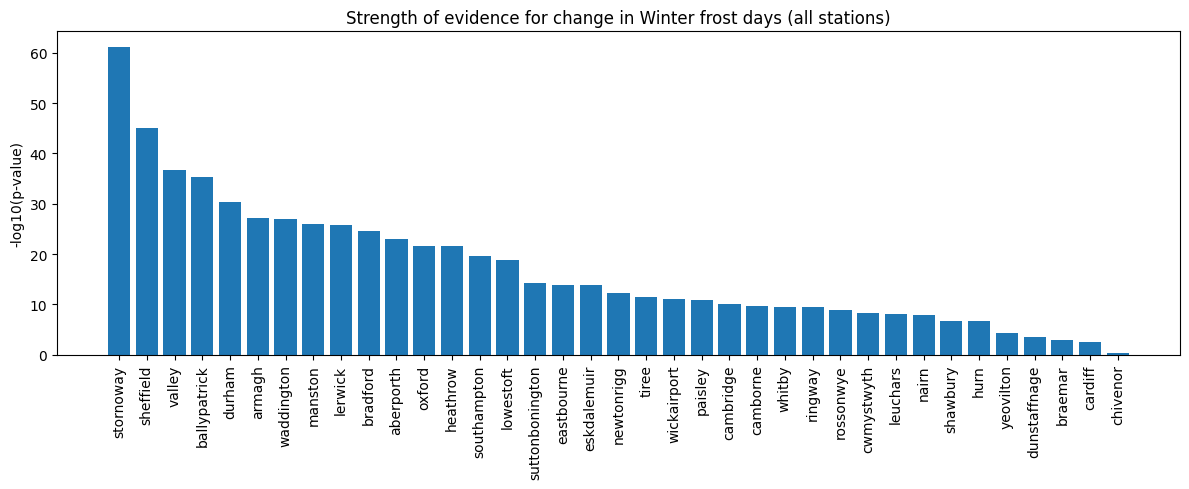

In [53]:

winter = results_37_df[results_37_df["Season"] == "Winter"].copy()
winter = winter.sort_values("p_value")

plt.figure(figsize=(12, 5))
plt.bar(range(len(winter)), -np.log10(winter["p_value"]))
plt.xticks(range(len(winter)), winter["station"], rotation=90)
plt.ylabel("-log10(p-value)")
plt.title("Strength of evidence for change in Winter frost days (all stations)")
plt.tight_layout()
plt.show()

#### Strength of Evidence for Change in Winter Frost Days (All Stations)

The plot above shows, for each station, the strength of evidence that winter frost frequencies have changed over time. The y-axis uses −log10(p-value), so larger bars correspond to stronger evidence. This ranking highlights clear variation across stations: most show very strong evidence of change, while a small number exhibit weaker but still notable signals. Presenting the results in this form provides an accessible way to compare all 37 stations without relying on long tables of p-values.


#### Section Summary

The chi-squared tests show that frost frequencies have changed over time at most UK stations. The Armagh example illustrates this clearly, with several decades showing large deviations from expected counts. Across all 37 stations, winter, spring, and autumn show widespread evidence of change, while summer shows little due to the rarity of frost.



### Summary of Statistical Evidence

Looking across all three tasks, the analyses show a consistent picture: several aspects of the UK’s weather have changed over time, and these changes are visible both in simple descriptive trends and in more formal statistical tests. Even before applying any models, the plots **exploring Climate trends in Leuchars, Cardiff, and Eastbourne** suggested warmer temperatures in recent decades and fewer frost days in many parts of the country. These initial observations are supported strongly by the statistical results.

In my exploration of the **trend in average max temperature**, the regression analysis of maximum temperatures showed that most stations have experienced a gradual warming trend. The confidence intervals from the bootstrap method confirm that these increases are unlikely to be due to random variation. When predicting future temperatures for 2075, the results for stations such as Armagh and Cambridge suggest noticeably higher August temperatures compared with past decades. This reinforces the broader impression that the UK’s climate is warming and that these changes are likely to continue.

My Chi-Squared results of the **changing air frost patterns** adds another important piece of evidence: the decline in frost days. The chi-squared tests show that, at most stations, the number of frost days has changed significantly over the decades, especially in winter. Almost every station shows this pattern, which suggests that the decline is widespread rather than limited to one region. At the same time, the strength of the evidence varies between locations, with stations that have long records showing the clearest signals. Coastal or more southerly stations sometimes show weaker evidence, which is reasonable given their milder local climates.

Although the analyses clearly show that changes have taken place, they cannot fully explain why. The results are consistent with the broader understanding that rising temperatures reduce the likelihood of frost, but this dataset does not allow us to separate the effects of global warming, local geography, or other influences such as urban development.

Further work could look at additional weather variables or use more detailed regional climate information to understand the drivers behind these changes. Extending the dataset or incorporating high-resolution modern data could also help. Overall, the evidence from these tasks paints a clear picture: UK weather patterns,especially temperature and frost frequency, have shifted noticeably over time, and many of these changes are both statistically significant and practically meaningful.